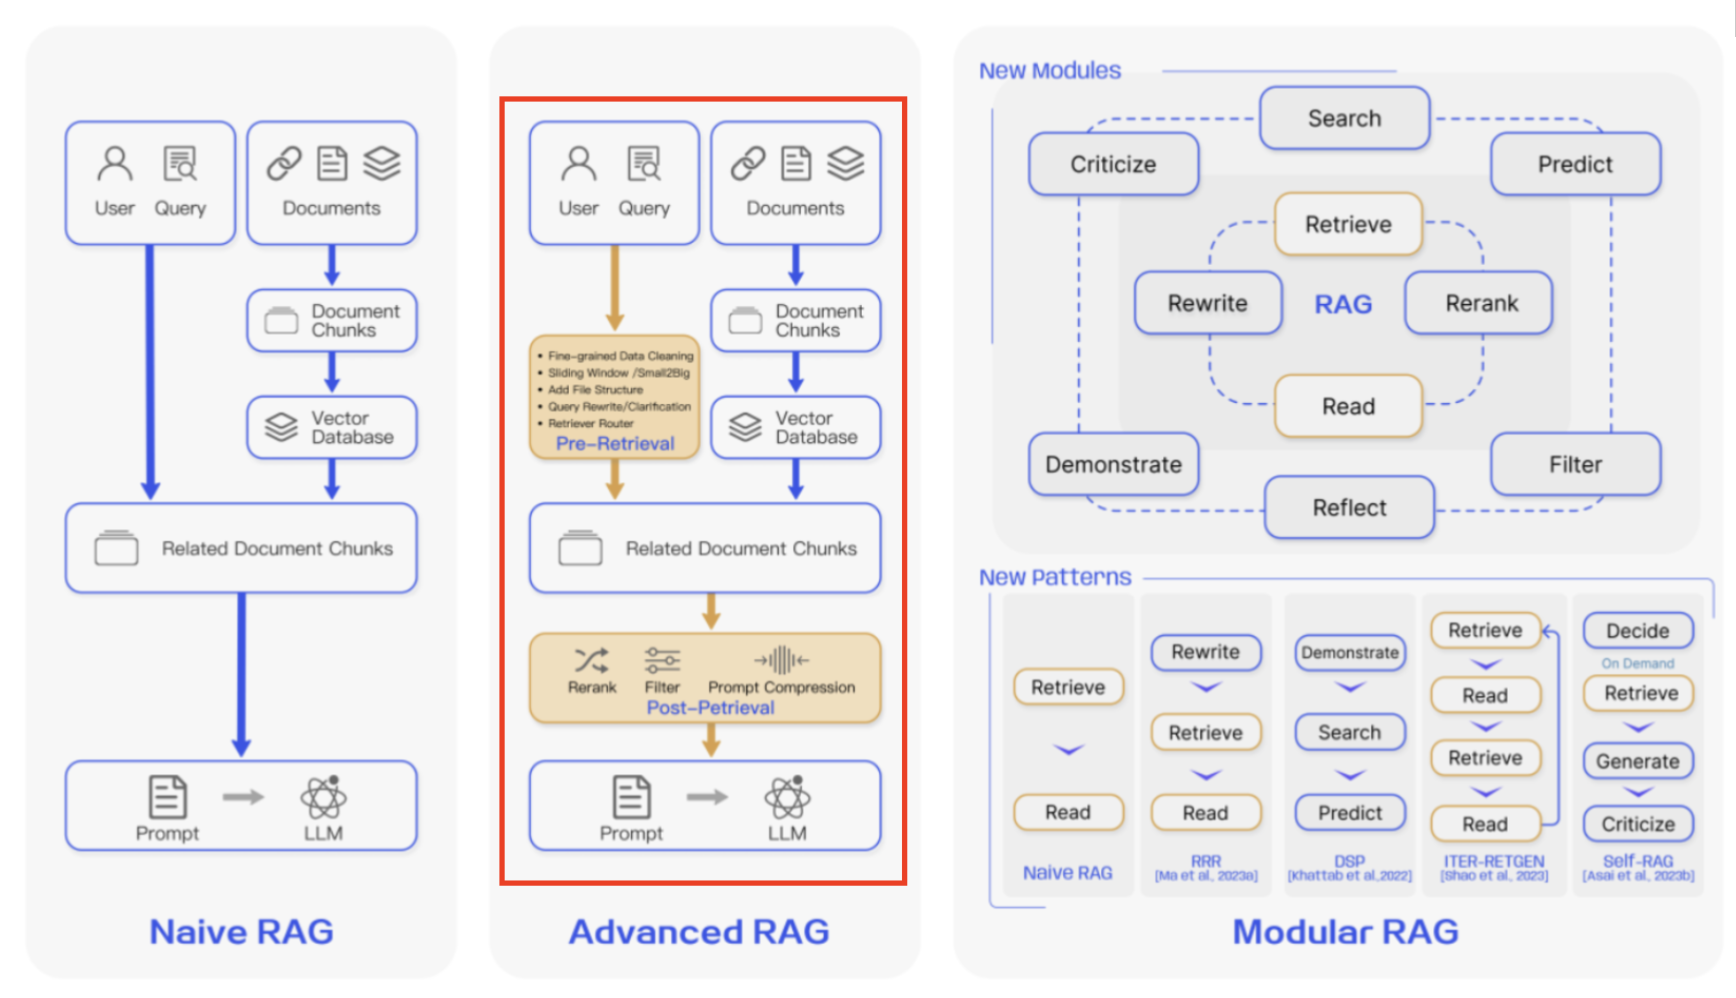

# [Qdrant VectorDB](https://qdrant.tech/documentation/quickstart/)


## 1. Qdrant란?

Qdrant는 고성능 벡터 유사도 검색을 위한 오픈소스 벡터 데이터베이스입니다.


### 주요 특징
- **고성능**: Rust로 작성되어 매우 빠른 검색 속도 제공
- **확장 가능한 필터링**: 복잡한 조건을 사용한 필터링 지원
- **페이로드 저장**: 벡터와 함께 JSON 형태의 메타데이터 저장
- **REST API & gRPC**: 다양한 프로토콜을 통한 접근 가능
- **클라우드 네이티브**: Docker, Kubernetes 등 컨테이너 환경에 최적화
- **LangChain 통합**: LangChain과 완벽하게 통합되어 RAG 시스템 구축 가능


### 사용 사례
- 시맨틱 검색 (Semantic Search)
- 추천 시스템 (Recommendation Systems)
- 이미지/비디오 검색
- RAG (Retrieval Augmented Generation) 시스템
- 중복 탐지 (Duplicate Detection)
- 이상 탐지 (Anomaly Detection)


## 2. Qdrant vs 다른 벡터 데이터베이스


### Qdrant의 장점
- **고성능**: Rust 기반으로 매우 빠른 검색 속도
- **풍부한 필터링**: SQL과 유사한 강력한 필터링 기능
- **확장성**: 수평적 확장 지원 (Horizontal Scaling)
- **관리 편의성**: 직관적인 REST API와 Web UI 제공
- **실시간 업데이트**: 실시간으로 데이터 추가/수정/삭제 가능
- **클라우드 지원**: Qdrant Cloud를 통한 관리형 서비스 제공


### 다른 솔루션과의 비교
- **Chroma**: 간단한 설정, 메모리 기반, 소규모 프로젝트에 적합
- **pgvector**: 기존 DB 활용, 중간 규모, 엔터프라이즈 환경
- **Qdrant**: 고성능, 풍부한 필터링, 중소규모에서 대규모까지 적합
- **Milvus**: 대규모 분산 환경, 높은 성능, 복잡한 설정


## 3. 설치 및 설정

Qdrant를 사용하기 위한 설치와 설정 방법을 알아보겠습니다.


### [Web UI 연결](http://localhost:6333/dashboard#/welcome) 
```url
http://localhost:6333/dashboard#/welcome
```

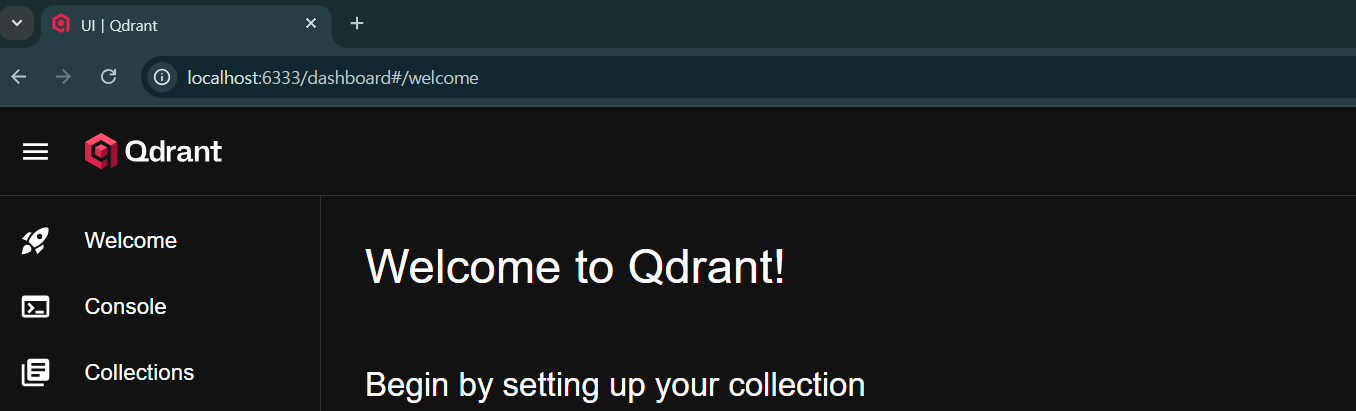

### Qdrant 클라이언트 연결


In [1]:
from qdrant_client import QdrantClient

client = QdrantClient(host="localhost", port=6333)

# Qdrant Cloud 연결
# client = QdrantClient(
#     url="https://your-cluster.qdrant.io",
#     api_key="your-api-key"
# )

print("Qdrant 클라이언트 연결 완료")


Qdrant 클라이언트 연결 완료


## [4. LangChain과 Qdrant 통합](https://docs.langchain.com/oss/python/langchain/knowledge-base#qdrant)

실제 텍스트 파일을 로드하여 Qdrant에 저장하고 검색하는 완전한 예제를 만들어보겠습니다.


### 텍스트 파일 로드


In [2]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("./data/rag-keywords.txt", encoding="utf-8")
documents = loader.load()
print(f"파일 로드 완료: {len(documents)}개 문서")


파일 로드 완료: 1개 문서


### 텍스트 분할


In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=50
)

splits = text_splitter.split_documents(documents)
print(f"텍스트 분할 완료: {len(splits)}개 청크")


텍스트 분할 완료: 41개 청크


### 임베딩 모델 설정


In [4]:
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")


### Qdrant 벡터스토어 생성


In [5]:
from langchain_qdrant import QdrantVectorStore

# Qdrant 벡터스토어 생성
vectorstore = QdrantVectorStore.from_documents(
    documents=splits,           # 분할된 문서
    embedding=embeddings,       # 임베딩 함수
    location="http://localhost:6333",        # 또는 인메모리 모드(":memory:")
    collection_name="rag_keywords",  # 컬렉션 이름
)

print("Qdrant 벡터스토어 생성 완료")


Qdrant 벡터스토어 생성 완료


```url
http://localhost:6333/dashboard#/collections
```

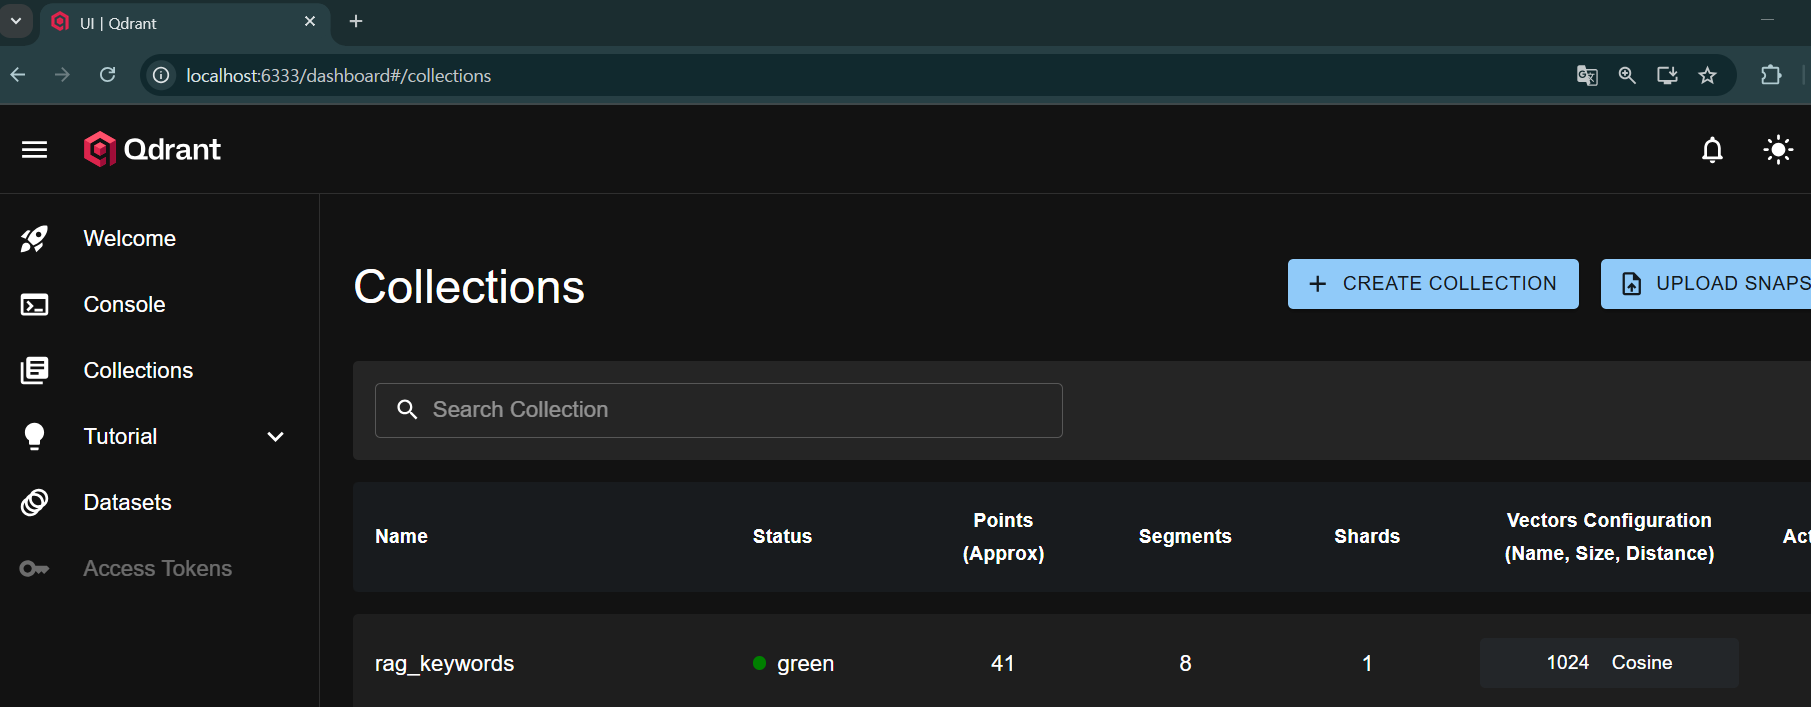

## 5. 데이터 저장 및 검색

Qdrant를 사용하여 문서를 저장하고 검색하는 방법을 알아보겠습니다.


### 샘플 문서 데이터


In [6]:
from langchain_core.documents import Document

sample_documents = [
    Document(
        page_content="인공지능은 인간의 지능을 모방하는 기술입니다.",
        metadata={"category": "AI", "topic": "기본개념", "source": "ai_basics.txt"}
    ),
    Document(
        page_content="머신러닝은 데이터로부터 패턴을 학습하는 AI의 한 분야입니다.",
        metadata={"category": "ML", "topic": "학습방법", "source": "ml_intro.txt"}
    ),
    Document(
        page_content="딥러닝은 신경망을 사용하는 머신러닝의 하위 분야입니다.",
        metadata={"category": "DL", "topic": "신경망", "source": "dl_guide.txt"}
    ),
    Document(
        page_content="자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.",
        metadata={"category": "NLP", "topic": "언어처리", "source": "nlp_handbook.txt"}
    )
]

print(f"샘플 문서 {len(sample_documents)}개가 준비되었습니다.")
for i, doc in enumerate(sample_documents, 1):
    print(f"{i}. {doc.page_content[:30]}... (카테고리: {doc.metadata['category']})")


샘플 문서 4개가 준비되었습니다.
1. 인공지능은 인간의 지능을 모방하는 기술입니다.... (카테고리: AI)
2. 머신러닝은 데이터로부터 패턴을 학습하는 AI의 한 분야... (카테고리: ML)
3. 딥러닝은 신경망을 사용하는 머신러닝의 하위 분야입니다.... (카테고리: DL)
4. 자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 ... (카테고리: NLP)


### 추가 벡터스토어 생성 (샘플 문서용)


In [7]:
# 샘플 문서를 위한 별도의 벡터스토어
sample_vectorstore = QdrantVectorStore.from_documents(
    documents=sample_documents,
    embedding=embeddings,
    location="http://localhost:6333",        # 또는 인메모리 모드(":memory:")
    collection_name="sample_docs",
)

print("샘플 벡터스토어 생성 완료")


샘플 벡터스토어 생성 완료


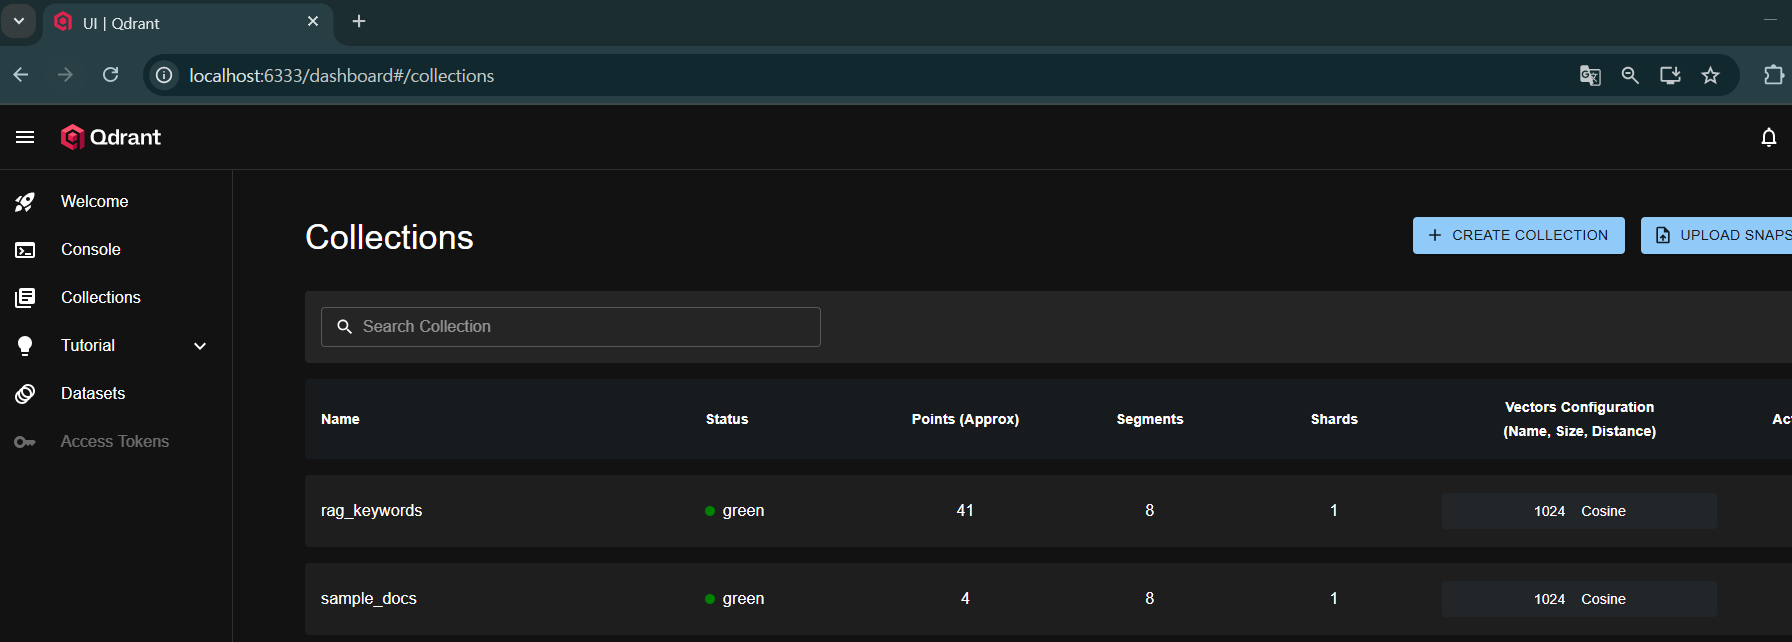

### 유사도 검색


In [9]:
def similarity_search_example(vectorstore, query, k=3):
    """유사도 검색 예제"""
    
    try:
        # 기본 유사도 검색
        results = vectorstore.similarity_search(query, k=k)
        
        print(f"검색 쿼리: '{query}'")
        print(f"검색 결과 ({len(results)}개):")
        print("-" * 50)
        
        for i, doc in enumerate(results, 1):
            print(f"{i}. {doc.page_content}")
            print(f"   메타데이터: {doc.metadata}")
            print()
            
        return results
    except Exception as e:
        print(f"검색 중 오류 발생: {e}")
        return []


In [10]:
results = similarity_search_example(sample_vectorstore, "신경망에 대해 알려주세요")


검색 쿼리: '신경망에 대해 알려주세요'
검색 결과 (3개):
--------------------------------------------------
1. 딥러닝은 신경망을 사용하는 머신러닝의 하위 분야입니다.
   메타데이터: {'category': 'DL', 'topic': '신경망', 'source': 'dl_guide.txt', '_id': 'bc9bfb98-41fa-4ab5-9637-bdd8389f5a38', '_collection_name': 'sample_docs'}

2. 머신러닝은 데이터로부터 패턴을 학습하는 AI의 한 분야입니다.
   메타데이터: {'category': 'ML', 'topic': '학습방법', 'source': 'ml_intro.txt', '_id': '8384806c-ceb4-4c36-97ba-25b83b95df9c', '_collection_name': 'sample_docs'}

3. 자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.
   메타데이터: {'category': 'NLP', 'topic': '언어처리', 'source': 'nlp_handbook.txt', '_id': 'a5207247-19a3-48ff-9997-e4e60aba4f1c', '_collection_name': 'sample_docs'}



In [11]:
results

[Document(metadata={'category': 'DL', 'topic': '신경망', 'source': 'dl_guide.txt', '_id': 'bc9bfb98-41fa-4ab5-9637-bdd8389f5a38', '_collection_name': 'sample_docs'}, page_content='딥러닝은 신경망을 사용하는 머신러닝의 하위 분야입니다.'),
 Document(metadata={'category': 'ML', 'topic': '학습방법', 'source': 'ml_intro.txt', '_id': '8384806c-ceb4-4c36-97ba-25b83b95df9c', '_collection_name': 'sample_docs'}, page_content='머신러닝은 데이터로부터 패턴을 학습하는 AI의 한 분야입니다.'),
 Document(metadata={'category': 'NLP', 'topic': '언어처리', 'source': 'nlp_handbook.txt', '_id': 'a5207247-19a3-48ff-9997-e4e60aba4f1c', '_collection_name': 'sample_docs'}, page_content='자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.')]

### 유사도 점수와 함께 검색


In [12]:
def similarity_search_with_score_example(vectorstore, query, k=3):
    """유사도 점수와 함께 검색"""
    try:
        # 유사도 점수와 함께 검색
        results = vectorstore.similarity_search_with_score(query, k=k)
        
        print(f"검색 쿼리: '{query}' (점수 포함)")
        print(f"검색 결과 ({len(results)}개):")
        print("-" * 50)
        
        for i, (doc, score) in enumerate(results, 1):
            print(f"{i}. {doc.page_content}")
            print(f"   유사도 점수: {score:.4f}")
            print(f"   메타데이터: {doc.metadata}")
            print()
            
        return results
    except Exception as e:
        print(f"검색 중 오류 발생: {e}")
        return []


In [13]:
results = similarity_search_with_score_example(sample_vectorstore, "인공지능 기술")


검색 쿼리: '인공지능 기술' (점수 포함)
검색 결과 (3개):
--------------------------------------------------
1. 자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.
   유사도 점수: 0.5311
   메타데이터: {'category': 'NLP', 'topic': '언어처리', 'source': 'nlp_handbook.txt', '_id': 'a5207247-19a3-48ff-9997-e4e60aba4f1c', '_collection_name': 'sample_docs'}

2. 인공지능은 인간의 지능을 모방하는 기술입니다.
   유사도 점수: 0.4981
   메타데이터: {'category': 'AI', 'topic': '기본개념', 'source': 'ai_basics.txt', '_id': '04ec6460-870c-4883-8e5e-e7ed0bc3a2cb', '_collection_name': 'sample_docs'}

3. 머신러닝은 데이터로부터 패턴을 학습하는 AI의 한 분야입니다.
   유사도 점수: 0.4781
   메타데이터: {'category': 'ML', 'topic': '학습방법', 'source': 'ml_intro.txt', '_id': '8384806c-ceb4-4c36-97ba-25b83b95df9c', '_collection_name': 'sample_docs'}



In [14]:
results

[(Document(metadata={'category': 'NLP', 'topic': '언어처리', 'source': 'nlp_handbook.txt', '_id': 'a5207247-19a3-48ff-9997-e4e60aba4f1c', '_collection_name': 'sample_docs'}, page_content='자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.'),
  0.5311384),
 (Document(metadata={'category': 'AI', 'topic': '기본개념', 'source': 'ai_basics.txt', '_id': '04ec6460-870c-4883-8e5e-e7ed0bc3a2cb', '_collection_name': 'sample_docs'}, page_content='인공지능은 인간의 지능을 모방하는 기술입니다.'),
  0.49809727),
 (Document(metadata={'category': 'ML', 'topic': '학습방법', 'source': 'ml_intro.txt', '_id': '8384806c-ceb4-4c36-97ba-25b83b95df9c', '_collection_name': 'sample_docs'}, page_content='머신러닝은 데이터로부터 패턴을 학습하는 AI의 한 분야입니다.'),
  0.47813156)]

## 6. 고급 검색 기능

Qdrant의 고급 검색 기능들을 알아보겠습니다.


### 메타데이터 필터링 검색

Qdrant는 강력한 필터링 기능을 제공합니다.


In [15]:
from qdrant_client.models import Filter, FieldCondition, MatchValue

def filtered_search_example(vectorstore, query, filter_dict, k=3):
    """메타데이터로 필터링된 검색"""
    try:
        # LangChain의 Qdrant는 메타데이터를 'metadata.' prefix로 저장
        # 따라서 키에 'metadata.'를 추가해야 함
        metadata_key = f"metadata.{filter_dict['key']}"
        
        filter_condition = Filter(
            must=[
                FieldCondition(
                    key=metadata_key,  # 'metadata.category' 형식으로
                    match=MatchValue(value=filter_dict['value'])
                )
            ]
        )

        # Qdrant 필터를 사용한 검색
        results = vectorstore.similarity_search(
            query, 
            k=k,
            filter=filter_condition
        )
        
        print(f"검색 쿼리: '{query}'")
        print(f"필터 조건: {filter_dict} (실제 키: {metadata_key})")
        print(f"검색 결과 ({len(results)}개):")
        print("-" * 50)
        
        for i, doc in enumerate(results, 1):
            print(f"{i}. {doc.page_content}")
            print(f"   메타데이터: {doc.metadata}")
            print()
            
        return results
    except Exception as e:
        print(f"필터링 검색 중 오류 발생: {e}")
        import traceback
        traceback.print_exc()
        return []


In [16]:
# AI 카테고리만 검색
# 샘플 데이터: AI(인공지능), ML(머신러닝), DL(딥러닝), NLP(자연어처리)
results = filtered_search_example(sample_vectorstore, "인공지능 기술", 
            {"key":"category", "value":"AI"})


검색 쿼리: '인공지능 기술'
필터 조건: {'key': 'category', 'value': 'AI'} (실제 키: metadata.category)
검색 결과 (1개):
--------------------------------------------------
1. 인공지능은 인간의 지능을 모방하는 기술입니다.
   메타데이터: {'category': 'AI', 'topic': '기본개념', 'source': 'ai_basics.txt', '_id': '04ec6460-870c-4883-8e5e-e7ed0bc3a2cb', '_collection_name': 'sample_docs'}



In [17]:
results

[Document(metadata={'category': 'AI', 'topic': '기본개념', 'source': 'ai_basics.txt', '_id': '04ec6460-870c-4883-8e5e-e7ed0bc3a2cb', '_collection_name': 'sample_docs'}, page_content='인공지능은 인간의 지능을 모방하는 기술입니다.')]

### MMR (Maximal Marginal Relevance) 검색

MMR은 관련성과 다양성을 모두 고려한 검색 방법입니다.


In [18]:
def mmr_search_example(vectorstore, query, k=3, fetch_k=10, lambda_mult=0.5):
    """MMR 검색 예제"""
    try:
        # MMR 검색
        # lambda_mult: 0에 가까우면 다양성 우선, 1에 가까우면 관련성 우선
        results = vectorstore.max_marginal_relevance_search(
            query, 
            k=k,
            fetch_k=fetch_k,  # 먼저 가져올 후보 문서 수
            lambda_mult=lambda_mult  # 관련성 vs 다양성 비율
        )
        
        print(f"검색 쿼리: '{query}'")
        print(f"MMR 검색 결과 (lambda={lambda_mult}):")
        print("-" * 50)
        
        for i, doc in enumerate(results, 1):
            print(f"{i}. {doc.page_content}")
            print(f"   메타데이터: {doc.metadata}")
            print()
            
        return results
    except Exception as e:
        print(f"MMR 검색 중 오류 발생: {e}")
        return []


In [19]:
results = mmr_search_example(
    sample_vectorstore, "머신러닝 학습", k=3, lambda_mult=0.5)


검색 쿼리: '머신러닝 학습'
MMR 검색 결과 (lambda=0.5):
--------------------------------------------------
1. 머신러닝은 데이터로부터 패턴을 학습하는 AI의 한 분야입니다.
   메타데이터: {'category': 'ML', 'topic': '학습방법', 'source': 'ml_intro.txt', '_id': '8384806c-ceb4-4c36-97ba-25b83b95df9c', '_collection_name': 'sample_docs'}

2. 자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.
   메타데이터: {'category': 'NLP', 'topic': '언어처리', 'source': 'nlp_handbook.txt', '_id': 'a5207247-19a3-48ff-9997-e4e60aba4f1c', '_collection_name': 'sample_docs'}

3. 딥러닝은 신경망을 사용하는 머신러닝의 하위 분야입니다.
   메타데이터: {'category': 'DL', 'topic': '신경망', 'source': 'dl_guide.txt', '_id': 'bc9bfb98-41fa-4ab5-9637-bdd8389f5a38', '_collection_name': 'sample_docs'}



In [20]:
results

[Document(metadata={'category': 'ML', 'topic': '학습방법', 'source': 'ml_intro.txt', '_id': '8384806c-ceb4-4c36-97ba-25b83b95df9c', '_collection_name': 'sample_docs'}, page_content='머신러닝은 데이터로부터 패턴을 학습하는 AI의 한 분야입니다.'),
 Document(metadata={'category': 'NLP', 'topic': '언어처리', 'source': 'nlp_handbook.txt', '_id': 'a5207247-19a3-48ff-9997-e4e60aba4f1c', '_collection_name': 'sample_docs'}, page_content='자연어처리는 컴퓨터가 인간의 언어를 이해하고 생성하는 기술입니다.'),
 Document(metadata={'category': 'DL', 'topic': '신경망', 'source': 'dl_guide.txt', '_id': 'bc9bfb98-41fa-4ab5-9637-bdd8389f5a38', '_collection_name': 'sample_docs'}, page_content='딥러닝은 신경망을 사용하는 머신러닝의 하위 분야입니다.')]

## 7. LCEL 방식의 RAG 체인

Qdrant와 LLM을 결합하여 실제 질의응답 시스템을 구축해보겠습니다.


### LLM 설정


In [21]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    num_predict=256,
    keep_alive="5m"
)


### RAG 체인 구성


In [22]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient

# Qdrant 클라이언트 생성
client = QdrantClient(host="localhost", port=6333)

# 기존 컬렉션에 연결
vectorstore = QdrantVectorStore(
    client=client,
    collection_name="rag_keywords",  # 기존 컬렉션 이름
    embedding=embeddings
)

# Retriever 설정
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

In [23]:
from langchain_core.prompts import ChatPromptTemplate

# 프롬프트 템플릿 정의
prompt = ChatPromptTemplate.from_template("""
    Answer the question based on the context:

    <context>
    {context}
    </context>

    Question: {question}
""")

In [24]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# 문서를 문자열로 변환하는 함수
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# LCEL 방식의 RAG 체인 구성
qa_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

print("RAG 체인 구성 완료")


RAG 체인 구성 완료


### 질문 답변 실행


In [25]:
# 질문 답변 실행
question = "딥러닝이란 무엇인가요?"

# LCEL 체인에 질문을 문자열로 전달
answer = qa_chain.invoke(question)

print(f"질문: {question}")
print(f"답변: {answer}")


질문: 딥러닝이란 무엇인가요?
답변: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.


### 다양한 질문 테스트


In [26]:
def ask_question(qa_chain, question):
    """질문에 대한 답변을 출력하는 함수"""
    print(f"\n{'='*60}")
    print(f"질문: {question}")
    print(f"{'='*60}")
    
    # LCEL 체인에 질문을 문자열로 전달
    answer = qa_chain.invoke(question)
    print(f"답변: {answer}")
    print(f"{'='*60}\n")
    
    return answer


In [27]:
# 여러 질문 테스트
questions = [
    "벡터 데이터베이스란 무엇인가요?",
    "임베딩의 역할은 무엇인가요?",
]

for q in questions:
    ask_question(qa_chain, q)



질문: 벡터 데이터베이스란 무엇인가요?
답변: 벡터스토어는 벡터 형식으로 변환된 데이터를 저장하는 시스템입니다. 이는 검색, 분류 및 기타 데이터 분석 작업에 사용됩니다.


질문: 임베딩의 역할은 무엇인가요?
답변: 임베딩의 역할은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡터로 변환하는 것입니다. 이를 통해 컴퓨터가 텍스트를 이해하고 처리할 수 있게 합니다.

